In [4]:
import pandas as pd
import re
import string
import nltk
import requests

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd


APP_ID = "com.facebook.katana"
NB_REVIEWS = 500

result, _ = reviews(
    APP_ID,
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=NB_REVIEWS
)

data = []

for r in result:
    if r['content'].strip() != "":
        data.append({
            "commentaire": r['content'],
            "rating": r['score'],
            "date": r['at'],
            "platform": "Google Play"
        })

df_gp = pd.DataFrame(data)

In [5]:
APP_ID = "284882215"  # Facebook iOS
NB_PAGES = 10

all_reviews = []

for page in range(1, NB_PAGES + 1):
    url = f"https://itunes.apple.com/rss/customerreviews/page={page}/id={APP_ID}/sortby=mostrecent/json"
    response = requests.get(url)

    if response.status_code != 200:
        break

    data = response.json()
    if "entry" not in data["feed"]:
        break

    reviews_as = data["feed"]["entry"][1:]

    for r in reviews_as:
        all_reviews.append({
            "commentaire": r["content"]["label"],
            "rating": int(r["im:rating"]["label"]),
            "date": r["updated"]["label"],
            "platform": "App Store"
        })

df_as = pd.DataFrame(all_reviews)

In [6]:
df = pd.concat([df_gp, df_as], ignore_index=True)
df.head()

,commentaire,rating,date,platform
0,i love face book 💖💖,5,2026-03-02 11:48:45,Google Play
1,very slow speed and nothing is to b good becau...,1,2026-03-02 11:45:29,Google Play
2,"I love Facebook,I can't regret installing it",5,2026-03-02 11:45:26,Google Play
3,Me and my husband all guy's god prayer 🤲 my ma...,5,2026-03-02 11:45:25,Google Play
4,thank you so much Facebook 💓,5,2026-03-02 11:45:11,Google Play


In [7]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["commentaire"].apply(preprocess_text)

df = df[df["clean_text"].str.strip() != ""]
df = df.drop_duplicates(subset="clean_text")

df[["commentaire", "clean_text"]].head()

,commentaire,clean_text
0,i love face book 💖💖,love face book
1,very slow speed and nothing is to b good becau...,slow speed nothing good reel viral
2,"I love Facebook,I can't regret installing it",love facebooki cant regret installing
3,Me and my husband all guy's god prayer 🤲 my ma...,husband guy god prayer marriage life plz futur...
4,thank you so much Facebook 💓,thank much facebook


In [10]:
def rating_to_sentiment(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

df[["rating", "sentiment"]].head()

,rating,sentiment
0,5,positive
1,1,negative
2,5,positive
3,5,positive
4,5,positive


In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

X.shape, y.shape

((796, 5000), (796,))

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [14]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75625
              precision    recall  f1-score   support

    negative       0.70      0.72      0.71        60
     neutral       0.17      0.09      0.12        11
    positive       0.83      0.87      0.85        89

    accuracy                           0.76       160
   macro avg       0.57      0.56      0.56       160
weighted avg       0.74      0.76      0.75       160



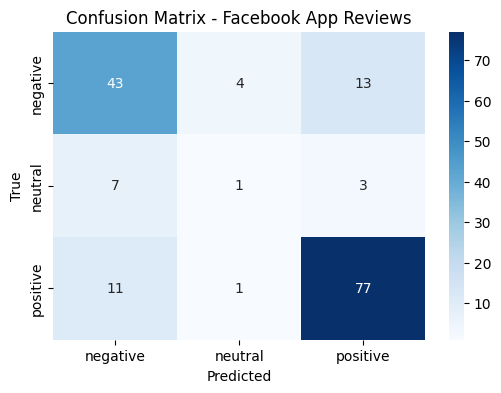

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Facebook App Reviews")
plt.show()

In [16]:
def predict_sentiment(text):
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])
    return model.predict(vec)[0]

predict_sentiment("Facebook app is slow and crashes a lot")

'negative'